In [1]:
import os
import re
import sys
import pandas as pd
import numpy as np
import tensorflow as tf
#import tensorflow_addons as tfa

from IPython.display import display
import matplotlib.pyplot as plt
import data_processing as dp

import custom_modules.PipeData as pidf

from keras_tqdm import TQDMNotebookCallback
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.utils import plot_model
from tensorflow.keras.layers import Reshape, Input, Dense, Flatten, Conv2D, Dropout, Conv2DTranspose
from tensorflow.keras.layers import MaxPooling2D, UpSampling2D, concatenate, BatchNormalization

In [2]:
#! pip install keras-tqdm

In [3]:
# paths for files with original data
PATH_TO_DATA = {
    'run_1': 
        ('data/Original data/Run1/run1_WM32_data.csv',
        'data/Original data/Run1/run1_WM32_defects.csv',
        'data/Original data/Run1/run1_WM32_pipe.csv'),
    'run_2':
        ('data/Original data/Run2/run2_WM32_data.csv',
        'data/Original data/Run2/run2_WM32_defects.csv',
        'data/Original data/Run2/run2_WM32_pipe.csv')
}

CROP_SIZE = 64
CROP_STEP = 20

# детерминация случайных величин, отвечающих за выбор первоначальных весов и биасов
tf.compat.v1.set_random_seed(290)
tf.random.set_seed(290)

# чтение данных
test_1 = pidf.PipeDataCsvWorker(*PATH_TO_DATA['run_1'])

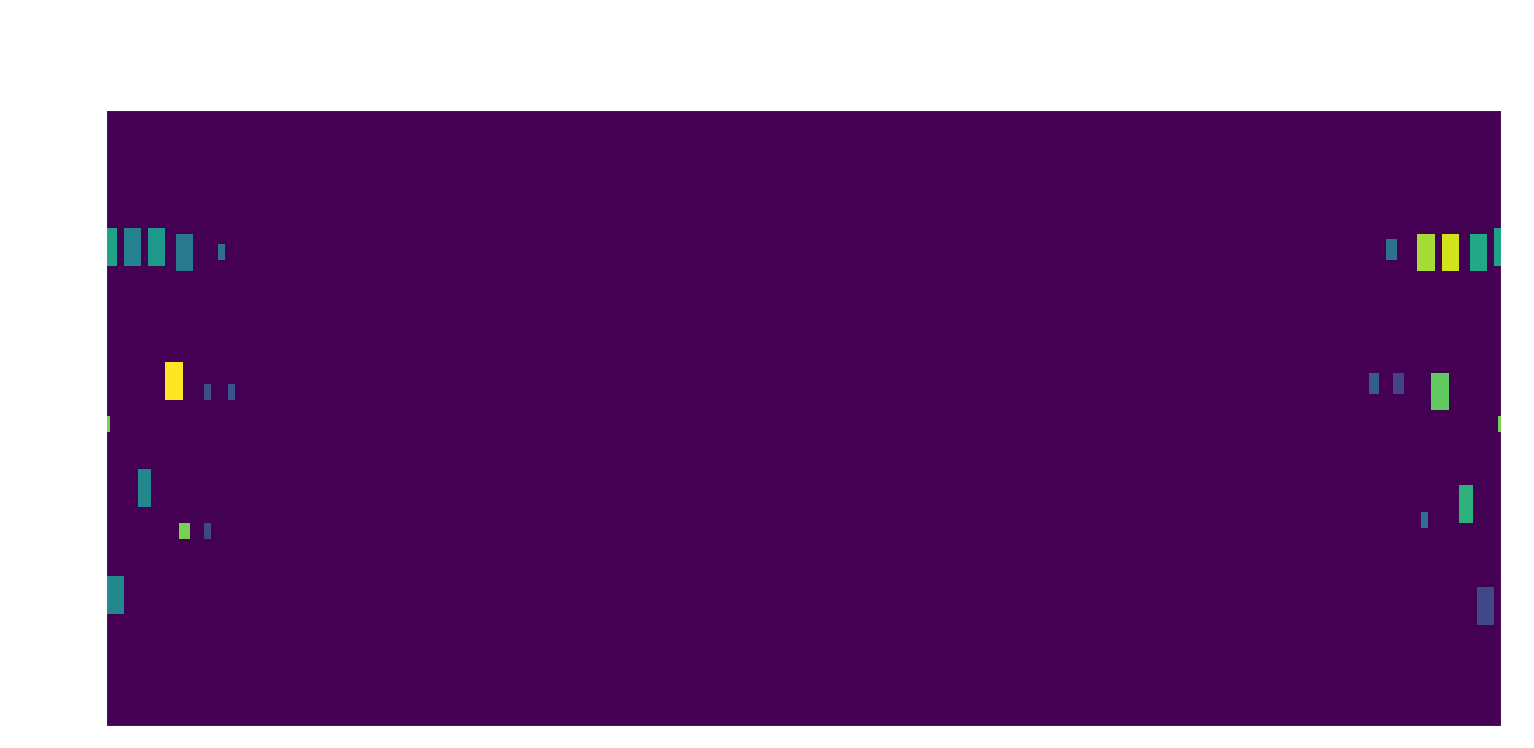

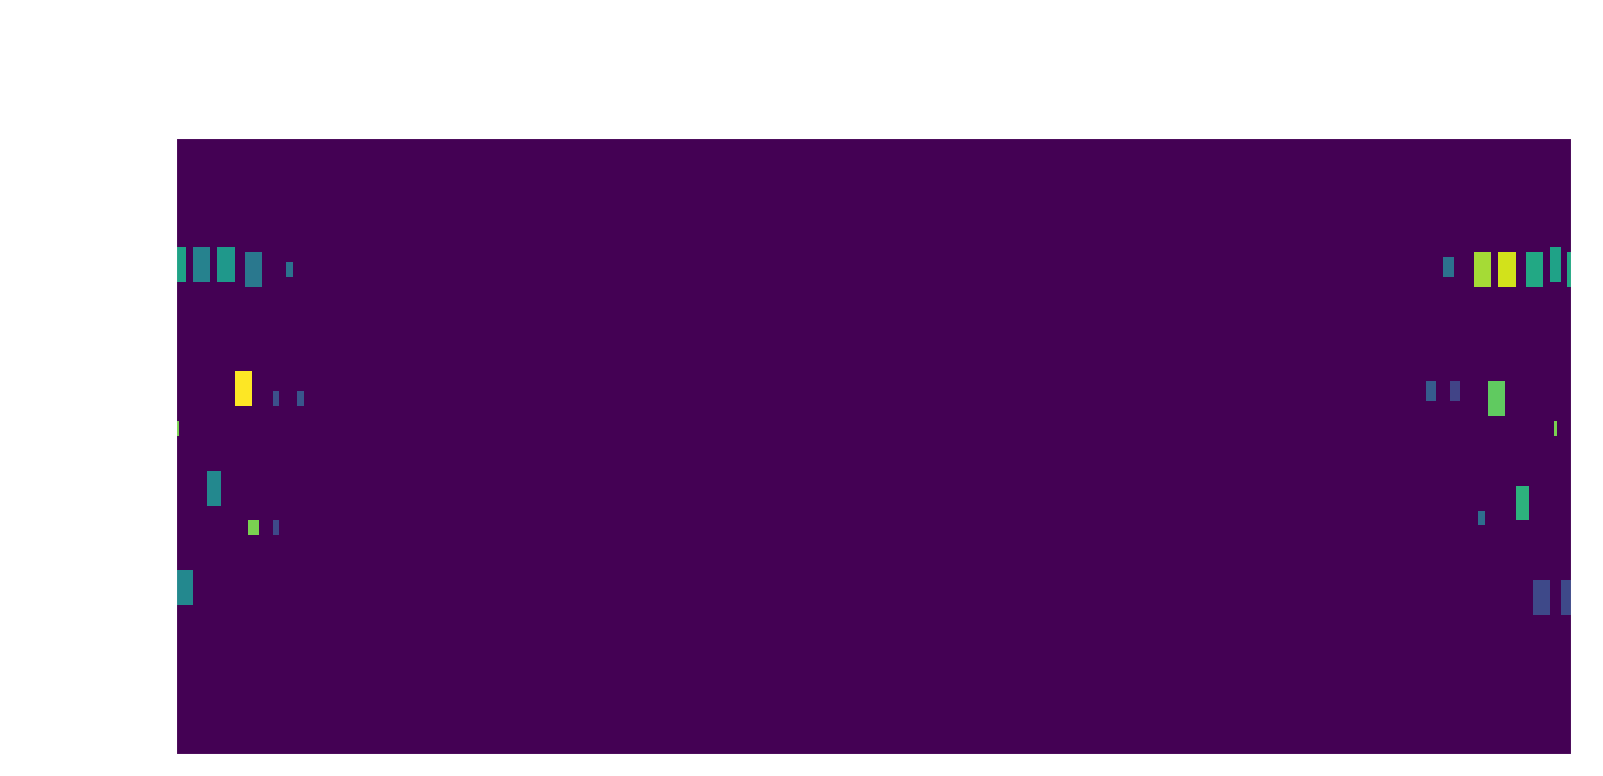

In [4]:
# Вывод считанных данных и их расширение для обучения
test_1.draw_defects_map(title='Считанная развернутая карта дефектов')
test_1.extend_dfs_for_crops_dividing(crop_size=CROP_SIZE, crop_step=CROP_STEP)
test_1.draw_defects_map(title=f'Расширенная развернутая карта дефектов для cr.size: {CROP_SIZE} и cr.step: {CROP_STEP}')

In [5]:
# Забрать данные из класса
x_data = test_1.get_data_df()
y_data = test_1.get_defects_df()
test_1 = None

In [6]:
# преобразовать данные к виду (измерение, размер х, размер у, каналы)
# для x_data_time каналы = 32
# для x_data_amp каналы = 32
# для y_data каналы = 1
(x_data_time,
x_data_amp) = dp.reshape_X_df_to_image_like_numpy(x_data, CROP_SIZE, CROP_STEP)
y_data = dp.reshape_Y_df_to_image_like_numpy(y_data, CROP_SIZE, CROP_STEP)

||||||||||||||||||
X df reshaping to 4D
Original df size:  (124, 404)
Crop windows height/width:  64
Crop windows step across rows and cols:  20
New X_time shape:  (72, 64, 64, 32)
New X_amp shape:  (72, 64, 64, 32)
||||||||||||||||||

||||||||||||||||||
Y df reshaping to 3D
Original df size:  (124, 404)
Crop windows height/width:  64
Crop windows step across rows and cols:  20
New numpy shape:  (72, 64, 64, 1)
||||||||||||||||||



In [7]:
# нормализовать входные данные
x_data_time = dp.normalize_data(x_data_time)
x_data_amp = dp.normalize_data(x_data_amp)

||||||||||||||||||
Data normalizing
arr_max before normalization: 44.5
arr_max after normalization: 1.0
arr_min after normalization: 0.0
||||||||||||||||||
||||||||||||||||||
Data normalizing
arr_max before normalization: 62.992
arr_max after normalization: 1.0
arr_min after normalization: -0.983743967487935
||||||||||||||||||


In [8]:
# Поделить кропы на дефектные и нет
(x_time_def, x_time_non_def), \
(x_amp_def, x_amp_non_def), \
(y_mask_def, y_mask_non_def) = dp.split_def_and_non_def_data(x_data_time, 
                                                            x_data_amp, 
                                                            y_data, CROP_SIZE)
x_data_time = x_data_amp = y_data = None

||||||||||||||||||
Defect and non defect data splitting
Orig X_time shape:  (72, 64, 64, 32)
Orig X_amp shape:  (72, 64, 64, 32)
Orig Y_mask shape:  (72, 64, 64, 1)
||||||||||||||||||
Defects nums calculating
Для карт высотой и шириной в 64
и общим кличеством: 72
дефекты присутствуеют на 19 картах
||||||||||||||||||

X_time_def shape:  (19, 64, 64, 32)
X_time_non_def shape:  (53, 64, 64, 32)

X_amp_def shape:  (19, 64, 64, 32)
X_amp_non_def shape:  (53, 64, 64, 32)

Y_mask_def shape:  (19, 64, 64, 1)
Y_mask_non_def shape:  (53, 64, 64, 1)

||||||||||||||||||



In [9]:
# Аугментировать данные
x_time_def = dp.augment_data(x_time_def) 
x_time_non_def = dp.augment_data(x_time_non_def) 

x_amp_def = dp.augment_data(x_amp_def) 
x_amp_non_def = dp.augment_data(x_amp_non_def) 

y_mask_def = dp.augment_data(y_mask_def) 
y_mask_non_def = dp.augment_data(y_mask_non_def) 

||||||||||||||||||
Data augmentation
Orig arr shape:  (19, 64, 64, 32)
||||||||||||
After 4 steps of 90 degree rotate
arr shape:  (76, 64, 64, 32)
||||||||||||
After horizontal full mirroring
arr shape:  (152, 64, 64, 32)
||||||||||||
After vertical full mirroring
arr shape:  (304, 64, 64, 32)
||||||||||||||||||

||||||||||||||||||
Data augmentation
Orig arr shape:  (53, 64, 64, 32)
||||||||||||
After 4 steps of 90 degree rotate
arr shape:  (212, 64, 64, 32)
||||||||||||
After horizontal full mirroring
arr shape:  (424, 64, 64, 32)
||||||||||||
After vertical full mirroring
arr shape:  (848, 64, 64, 32)
||||||||||||||||||

||||||||||||||||||
Data augmentation
Orig arr shape:  (19, 64, 64, 32)
||||||||||||
After 4 steps of 90 degree rotate
arr shape:  (76, 64, 64, 32)
||||||||||||
After horizontal full mirroring
arr shape:  (152, 64, 64, 32)
||||||||||||
After vertical full mirroring
arr shape:  (304, 64, 64, 32)
||||||||||||||||||

||||||||||||||||||
Data augmentation
Orig arr shape:  

In [10]:
def create_binary_arr_from_mask_arr(Y_mask):
    # создать binary_arr из binary_mask_arr
    print('||||||||||||||||||')
    print('Y 4*4 mask arr from Y mask arr creation')
    print('Y mask arr shape: ', Y_mask.shape)
    # Найдем на каких картинках есть дефекты
    new_Y_mask = list()
    center = Y_mask.shape[1] // 2 
    for i in range(Y_mask.shape[0]):
        top_left = True if np.sum(Y_mask[i,:center,:center]) > 0 else False
        top_right = True if np.sum(Y_mask[i,:center,center:]) > 0 else False
        bottom_left = True if np.sum(Y_mask[i,center:,:center]) > 0 else False
        bottom_right = True if np.sum(Y_mask[i,center:,center:]) > 0 else False
        
        new_Y_mask.append([[top_left, top_right],
                           [bottom_left, bottom_right]])

    new_Y_mask = np.array(new_Y_mask, dtype='bool')

    print('new_Y_mask arr shape: ', new_Y_mask.shape)
    print('||||||||||||||||||\n')

    return new_Y_mask

In [11]:
# создание выходных данных бинарного вида (одномерный массив типа bool)
y_mask_def = create_binary_arr_from_mask_arr(y_mask_def)
y_mask_non_def = create_binary_arr_from_mask_arr(y_mask_non_def)

||||||||||||||||||
Y 4*4 mask arr from Y mask arr creation
Y mask arr shape:  (304, 64, 64, 1)
new_Y_mask arr shape:  (304, 2, 2)
||||||||||||||||||

||||||||||||||||||
Y 4*4 mask arr from Y mask arr creation
Y mask arr shape:  (848, 64, 64, 1)
new_Y_mask arr shape:  (848, 2, 2)
||||||||||||||||||



In [12]:
# деление на тренировочную и валидационную выборки

val_data_percent = 0.2

X_time_train, X_time_val = dp.split_data_to_train_val_datasets([x_time_def,
                                                                x_time_non_def],
                                                                val_data_percent)

X_amp_train, X_amp_val = dp.split_data_to_train_val_datasets([x_amp_def,
                                                              x_amp_non_def],
                                                              val_data_percent)

Y_mask_train, Y_mask_val = dp.split_data_to_train_val_datasets([y_mask_def,
                                                                y_mask_non_def],
                                                                val_data_percent)

||||||||||||||||||
Data spliting to test, val and train datasets
Orig item shape:  (304, 64, 64, 32)
Orig item shape:  (848, 64, 64, 32)

Result arr_train shape:  (923, 64, 64, 32)
Result arr_val shape:  (229, 64, 64, 32)

||||||||||||||||||

||||||||||||||||||
Data spliting to test, val and train datasets
Orig item shape:  (304, 64, 64, 32)
Orig item shape:  (848, 64, 64, 32)

Result arr_train shape:  (923, 64, 64, 32)
Result arr_val shape:  (229, 64, 64, 32)

||||||||||||||||||

||||||||||||||||||
Data spliting to test, val and train datasets
Orig item shape:  (304, 2, 2)
Orig item shape:  (848, 2, 2)

Result arr_train shape:  (923, 2, 2)
Result arr_val shape:  (229, 2, 2)

||||||||||||||||||



In [13]:
# перемешивание данных

train_shuffled_indices = np.random.permutation(X_time_train.shape[0])
val_shuffled_indices = np.random.permutation(X_time_val.shape[0])

X_time_train = X_time_train[train_shuffled_indices]
X_amp_train = X_amp_train[train_shuffled_indices]
Y_mask_train = Y_mask_train[train_shuffled_indices]

X_time_val = X_time_val[val_shuffled_indices]
X_amp_val = X_amp_val[val_shuffled_indices]
Y_mask_val = Y_mask_val[val_shuffled_indices]

In [14]:
# что есть на данный момент

print('X_time_train.shape: ', X_time_train.shape)
print('X_amp_train.shape: ', X_amp_train.shape)
print('Y_binary_train.shape', Y_mask_train.shape)
print('\n')

print('X_time_val.shape: ', X_time_val.shape)
print('X_amp_val.shape: ', X_amp_val.shape)
print('Y_binary_val.shape', Y_mask_val.shape)
print('\n')

X_time_train.shape:  (923, 64, 64, 32)
X_amp_train.shape:  (923, 64, 64, 32)
Y_binary_train.shape (923, 2, 2)


X_time_val.shape:  (229, 64, 64, 32)
X_amp_val.shape:  (229, 64, 64, 32)
Y_binary_val.shape (229, 2, 2)




In [15]:
# всякие константы для последующей работы

#///////////////////////////////// для компиляции 

CMP_learning_rate = 0.000004 #0.04 # шаг сходимости back propogation
CMP_solver = keras.optimizers.Adam(CMP_learning_rate) # оптимизатор
#CMP_solver = keras.optimizers.SGD(CMP_learning_rate) # оптимизатор
CMP_loss_func = 'mean_squared_error'# функция потерь
#///////////////////////////////// для колбэков

    # для Early_stopping
#ES_patience = 15 # кол-во эпох без улучшений
#ES_min_delta = 0.0005 # минимальное улучшение параметра за cur_patience
#ES_monitor_parametr =  'loss' # отслеживаемый параметр 
#ES_save_best_weights = False # сохранять ли веса нейронки с лучшими результатами
    
    # для ReduceLROnPlateau
#RLPOP_monitor_parametr = 'loss'  # отслеживаемый параметр 
#RLPOP_factor = 0.4 # множитель для расчета нового шага сходимости (new_learning_rate = old_learning_rate*RLPOP_factor)
#RLPOP_patience = 10 # кол-во эпох без улучшений
#RLPOP_verbose = 1 # выводить ли прогресс изменения шага сходимости в его процессее
#RLPOP_mode = 'auto' # выбирает, уменьшать шаг сходимости при росте величины или при её уменьшении
#RLPOP_min_delta = 0.001 # порог изменения отслеживаемого значения
#RLPOP_cooldown = 0 # количество эпох до возобновления работы после изменения шага сходимости
#RLPOP_min_lr = 0 # минимальное значение шага сходимости

    # для CallbackList
CBL_add_history = True # вызывать ли колбэк History (если он не был довавлен вручную)
CBL_add_progbar = True # вызывать ли колбэк ProgbarLogger (если он не был довавлен вручную)
    
#///////////////////////////////// для тренировки

FIT_batch_size = 32 # размер bach при обучении/тестировании1
#FIT_shuffle = True # перемешивать ли данные
FIT_verbose = True # выводить ли прогресс обучения в его процессее
FIT_epochs = 5 # количество эпох обучения
#FIT_validation_split = 0.10 #0.20 # процент валидационных данных, отсекаемых из тестовой выборки

In [16]:
# Загрузка модели
#loaded_model = keras.models.load_model('data//NetWork_32x32_32x32_to_1__test_0dot0_ver_10.h5')

orig = keras.models.load_model('Networks//CNN//NetWork_(64x32+64x32)_to(1)_(test_0dot0366)_ver_10.h5')
orig.trainable=True

output = orig.get_layer('d_3_5').output
new_output = Reshape((2,2))(output)

# создадим новую модель

model = keras.models.Model(orig.input, new_output)
#model.summary()
model.compile(optimizer=CMP_solver, 
              loss=CMP_loss_func)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_time (InputLayer)        [(None, 64, 64, 32)  0           []                               
                                ]                                                                 
                                                                                                  
 input_amp (InputLayer)         [(None, 64, 64, 32)  0           []                               
                                ]                                                                 
                                                                                                  
 dconv_1_2 (Conv2D)             (None, 24, 24, 64)   51264       ['input_time[0][0]']             
                                                                                              

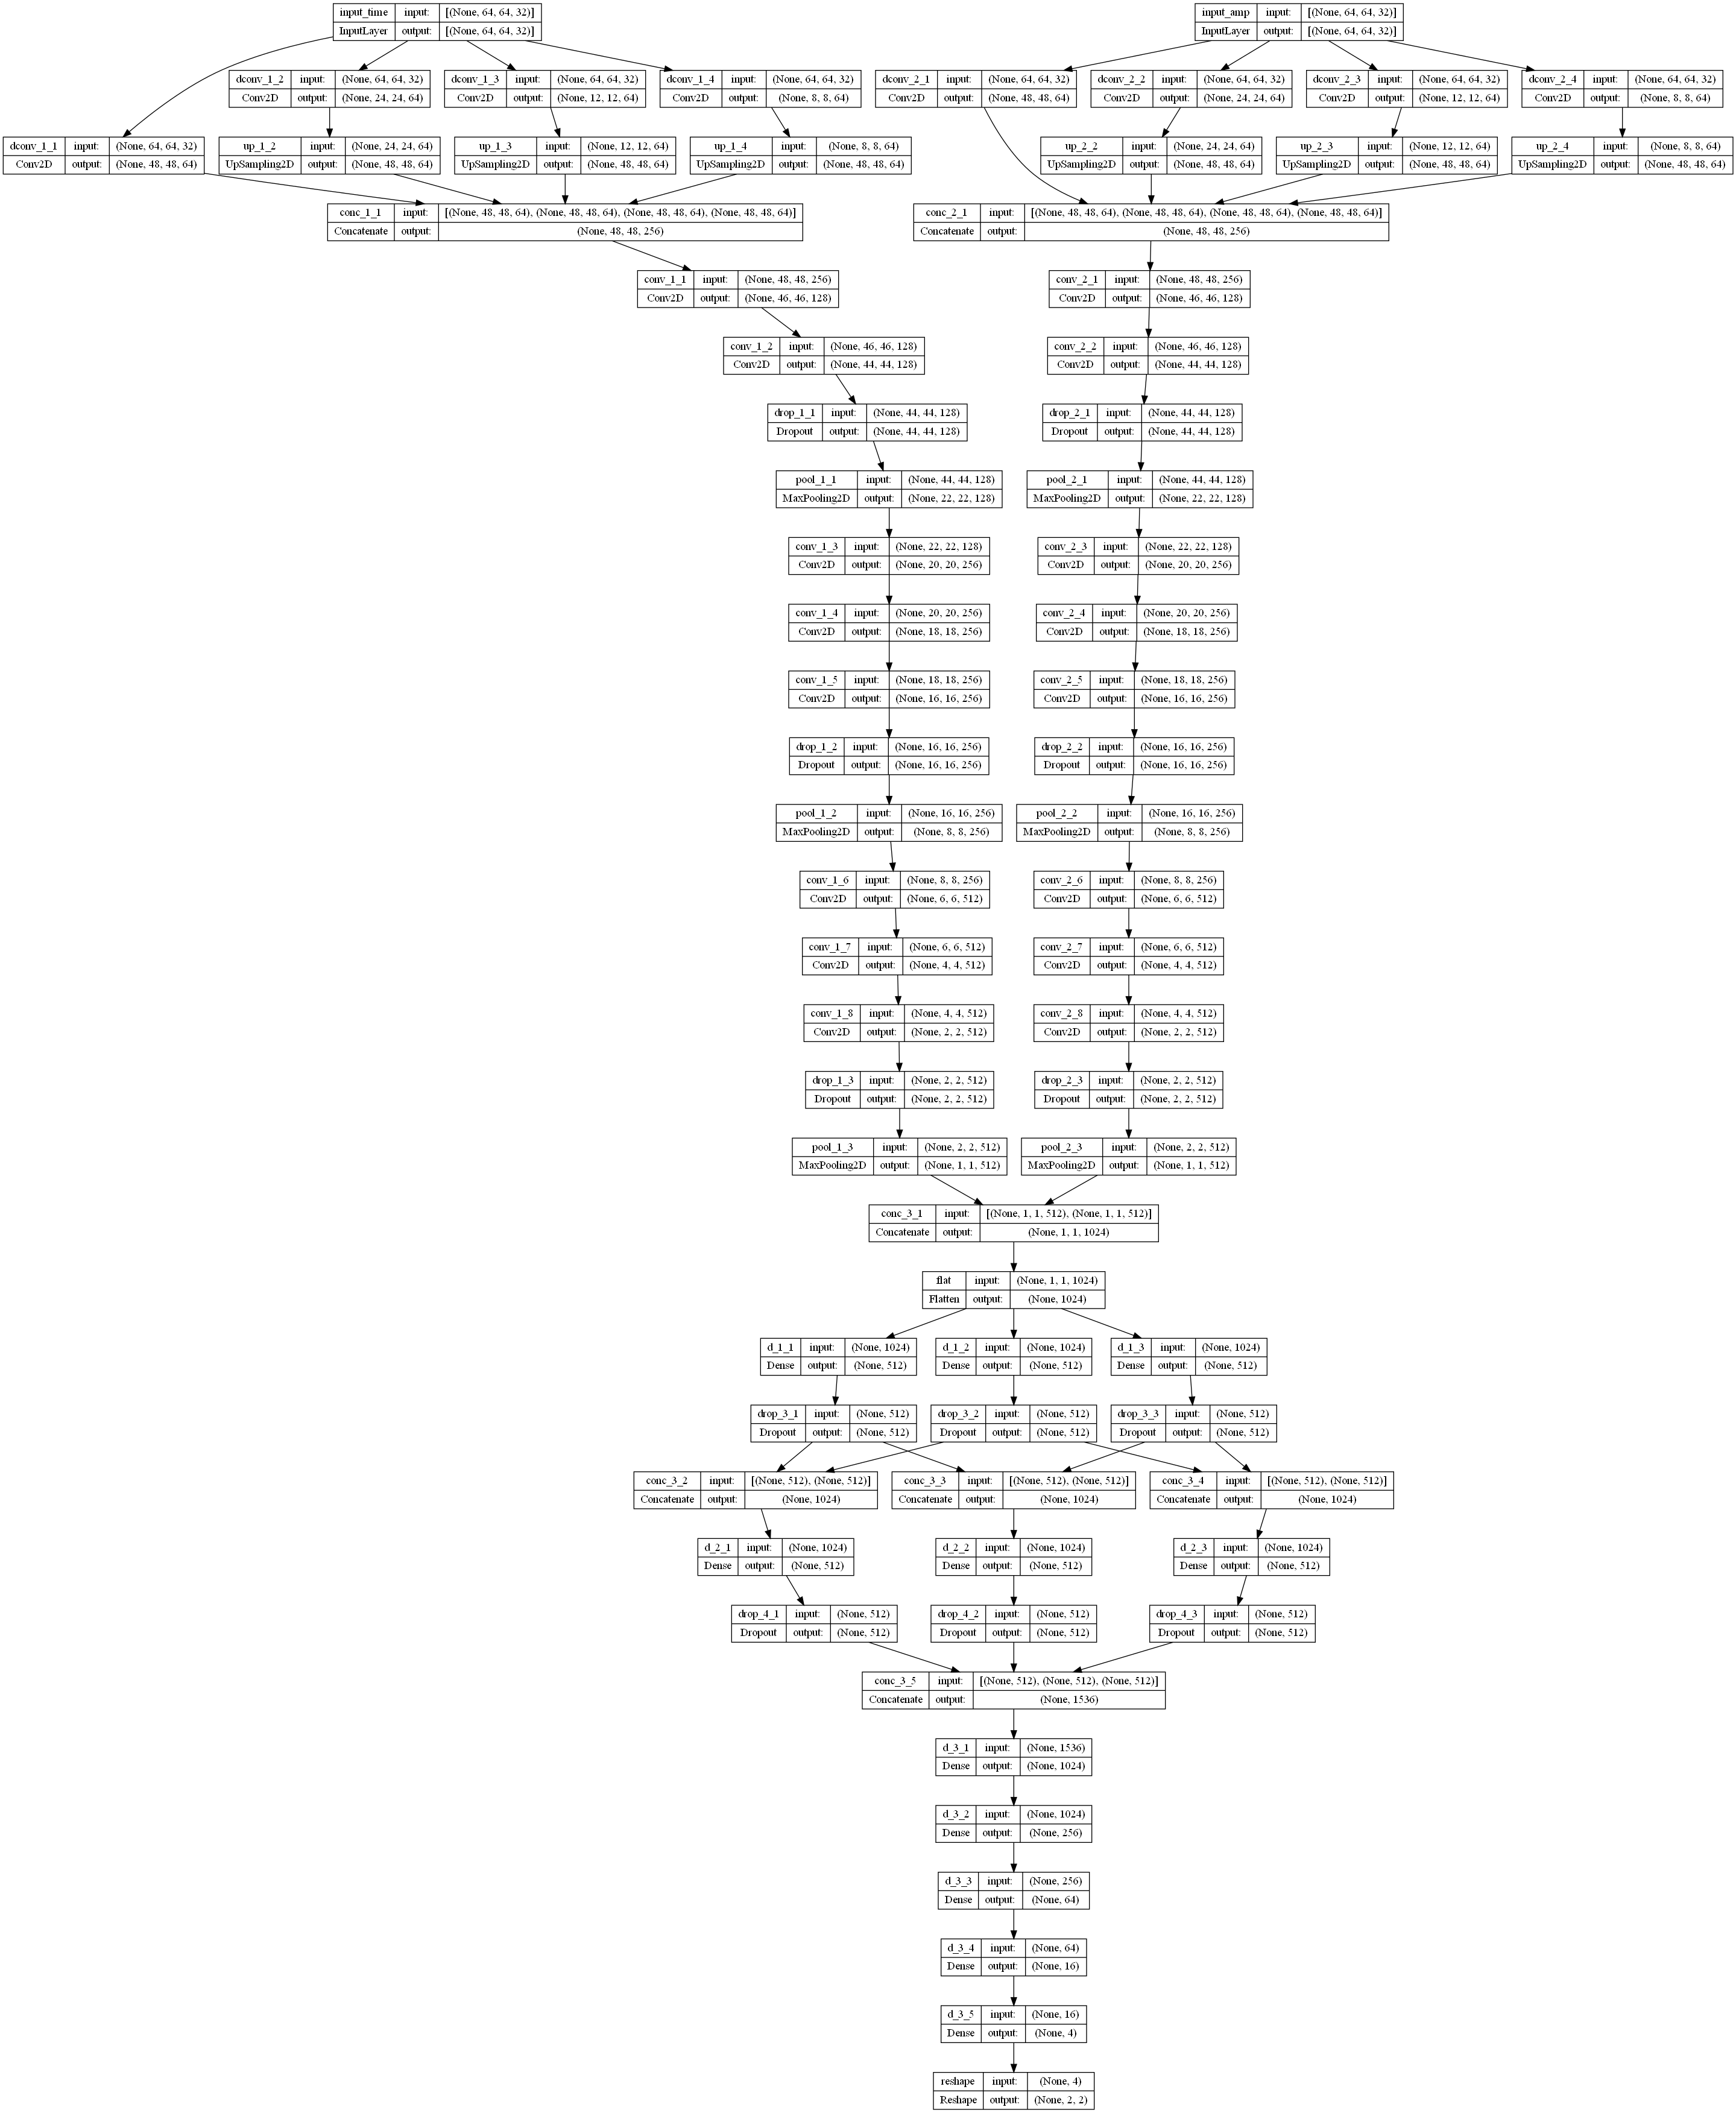

In [17]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [18]:
# Создание и настройка колбэков

callback_list = [] # массив колбэков до подачи в колбек "callbacklist"

FIT_callback_list = keras.callbacks.CallbackList(
            callbacks = callback_list, 
            add_history = CBL_add_history, 
            add_progbar = CBL_add_progbar, 
            model = model
            )

In [19]:
#! pip install ipywidgets

In [21]:
history = model.fit([X_time_train, X_amp_train],
                    Y_mask_train,
                    batch_size = FIT_batch_size, 
                    epochs = FIT_epochs, 
                    verbose = FIT_verbose, 
                    validation_data = ([X_time_val, X_amp_val], Y_mask_val), 
                    #shuffle = FIT_shuffle,
                    callbacks = FIT_callback_list)

29/29 [==============================] - 736s 25s/step - loss: 0.2736 - val_loss: 0.2775


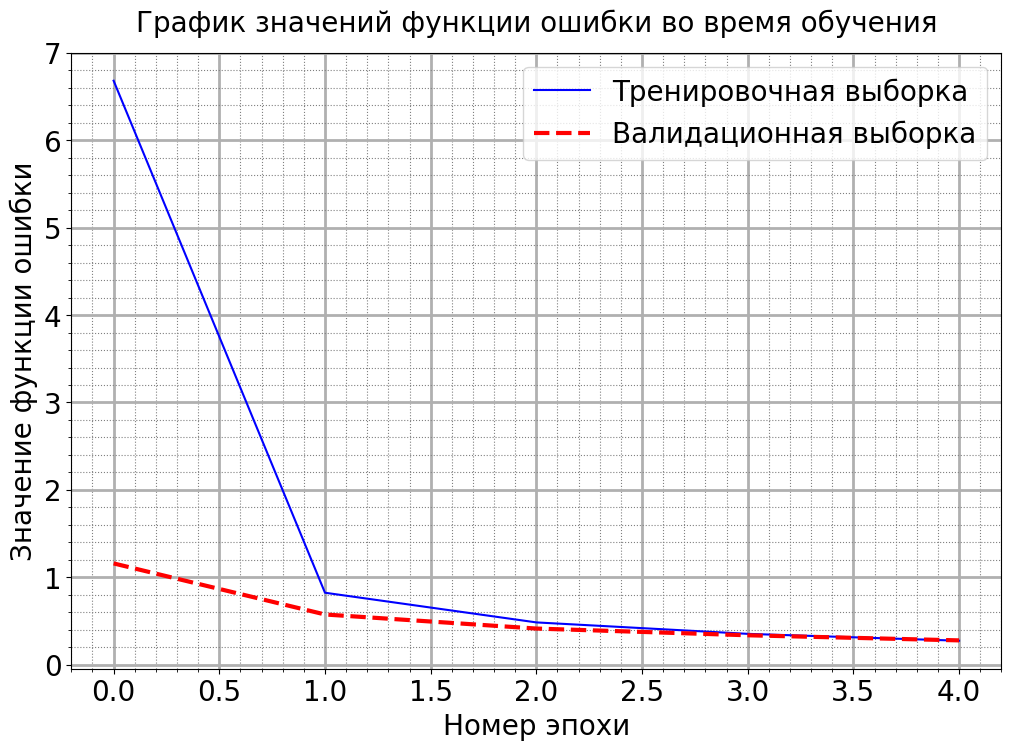

In [25]:
fig, ax = plt.subplots()

fig.set_figwidth(12)
fig.set_figheight(8)

plt.plot(history.history['loss'], 
         label='Тренировочная выборка',  linewidth=1.5, color='blue')
plt.plot(history.history['val_loss'], linestyle = '--', 
         label='Валидационная выборка',  linewidth=3, color='red')

ax.set_xlabel('Номер эпохи', fontsize=20)
ax.set_ylabel('Значение функции ошибки', fontsize=20)
ax.set_title(f"График значений функции ошибки во время обучения", fontsize=20, pad=15)

ax.patch.set_alpha(0)

#  Устанавливаем форматирование делений:
ax.tick_params(axis='both', which='both', labelsize = 20)

# Вывод и настройка сетки
ax.minorticks_on()
ax.grid(which='major', linewidth=2)
ax.grid(which='minor', color = 'gray', linestyle = ':')

ax.legend(fontsize = 20, facecolor = "white", loc = 'upper right')

plt.show()

In [24]:
# сохранение модели в файл

model.save("Networks//CNN//NetWork_(64x64+64x64)_to(4x4)_(test_0dot0)_ver_11.h5", save_format="h5")